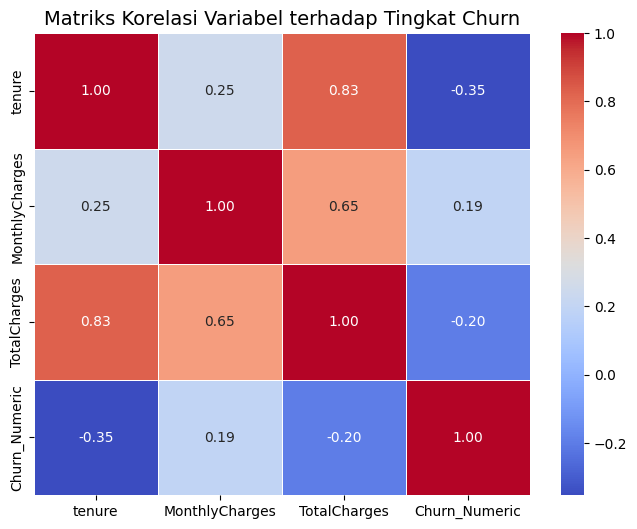

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Membaca data mentah
df = pd.read_csv('telco_raw.csv')

# 2. DATA CLEANING (Trik Profesional!)
# Di dataset ini, kolom TotalCharges (Total Tagihan) sering terbaca sebagai teks karena ada spasi kosong.
# Kita paksa ubah ke format angka numerik (errors='coerce' akan mengubah teks error menjadi nilai kosong/NaN)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
# Lalu kita isi nilai yang kosong tersebut dengan angka 0
df.fillna(0, inplace=True)

# 3. Transformasi Data Kategorik ke Numerik
# Komputer tidak bisa menghitung korelasi dari kata 'Yes' dan 'No', jadi kita ubah menjadi 1 dan 0.
df['Churn_Numeric'] = df['Churn'].map({'Yes': 1, 'No': 0})

# 4. Memilih variabel kuantitatif untuk diuji korelasinya
kolom_kuantitatif = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_Numeric']
matriks_korelasi = df[kolom_kuantitatif].corr()

# 5. Membuat Visualisasi Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(matriks_korelasi, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriks Korelasi Variabel terhadap Tingkat Churn', fontsize=14)
plt.show()